# E14 Isotropic Curvature Spectrum-Control Experiment

### Problem

This notebook is a controlled one-step experiment for the isotropic-curvature story. It does not train Matrix Sensing or Matrix Factorization. Instead it constructs synthetic gradient spectra and curvature growth functions, then compares update spectra directly.

The hypothesis is that full orthogonalization is not always optimal. Partial spectrum homogenization should be better in smooth curvature regimes, whereas polar orthogonalization should become competitive near phase-transition-like curvature.

### Synthetic Function Definitions

E14 is not a full training run. It is a one-step local quadratic model used to ask which update shape should be best under controlled spectra and curvature.

| name in notebook/code | definition | how to read it |
|---|---|---|
| `make_singular_values(kind, rank)` | constructs the synthetic gradient singular values $s_i$ for `flat`, `power`, `exponential`, or `spiked` spectra | Chooses the shape of the gradient spectrum. |
| `curvature_weights(kind, s)` | constructs diagonal local curvature weights $h_i$ from the gradient spectrum | Larger $h_i$ means moving in singular direction $i$ is more expensive. |
| `update_profile(method, s, gamma)` | constructs a unit-norm update direction from $s$ | `gradient` follows $s$, `normalized` rescales it, `spectral-normalized` divides by the largest singular value, `polar` makes all active directions equal, and `partial-homogenized` interpolates. |
| `predicted_improvement` | $\langle s,\Delta\rangle-\frac12\sum_i h_i\Delta_i^2$ | Larger is better; negative means the unit-radius step is locally harmful. |
| `local_quadratic_loss_change` | negative of predicted improvement over a range of step radii | Lower is better; below zero means predicted loss decrease. |


## Implementation Details: Skip Unless Modifying The Experiment

In [1]:
import math
import os
import pathlib
import sys
import time
from itertools import product

for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Documents/Workspace/MUONexperiment
torch   = 2.11.0


### Parameters And Synthetic Runs

In [2]:
NOTEBOOK_ID = "E14 isotropic curvature spectrum control"
D = 40
RANK = 10
SPECTRA = ["flat", "power", "exponential", "spiked"]
CURVATURES = ["quadratic", "polynomial", "exponential", "threshold"]
METHODS = ["gradient", "normalized", "spectral-normalized", "partial-homogenized", "polar"]
GAMMAS = [0.0, 0.25, 0.5, 0.75, 1.0]
print(f"spectra={SPECTRA}")
print(f"curvatures={CURVATURES}")


spectra=['flat', 'power', 'exponential', 'spiked']
curvatures=['quadratic', 'polynomial', 'exponential', 'threshold']


### Pseudocode

```text
construct singular values of a synthetic gradient
construct different update singular-value profiles
evaluate a one-step quadratic model: linear gain minus curvature penalty
compare which update profile has the largest predicted improvement
```

### Synthetic Objective Helpers

In [3]:
def make_singular_values(kind, rank):
    if kind == "flat":
        return np.ones(rank)
    if kind == "power":
        return np.arange(1, rank + 1, dtype=float) ** -1.0
    if kind == "exponential":
        return np.exp(-0.6 * np.arange(rank, dtype=float))
    if kind == "spiked":
        values = np.ones(rank) * 0.05
        values[0] = 1.0
        values[1] = 0.5
        return values
    raise ValueError(kind)


def curvature_weights(kind, s):
    x = s / max(np.max(s), 1e-12)
    if kind == "quadratic":
        return np.ones_like(s)
    if kind == "polynomial":
        return 1.0 + 10.0 * x**2
    if kind == "exponential":
        return np.exp(3.0 * x)
    if kind == "threshold":
        return np.where(x > 0.35, 30.0, 1.0)
    raise ValueError(kind)


def update_profile(method, s, gamma=0.5):
    if method == "gradient":
        u = s.copy()
    elif method == "normalized":
        u = s / max(np.linalg.norm(s), 1e-12)
    elif method == "spectral-normalized":
        u = s / max(np.max(s), 1e-12)
    elif method == "partial-homogenized":
        # gamma=0 is gradient-like; gamma=1 is polar-like.
        u = s ** (1.0 - gamma)
    elif method == "polar":
        u = np.ones_like(s)
    else:
        raise ValueError(method)
    return u / max(np.linalg.norm(u), 1e-12)


def predicted_improvement(s, curvature, method, gamma=0.5, radius=1.0):
    # Improvement in a local model: <G, Delta> - 0.5 * sum_i h_i * Delta_i^2.
    delta = radius * update_profile(method, s, gamma=gamma)
    h = curvature_weights(curvature, s)
    linear_gain = float(np.dot(s, delta))
    curvature_penalty = 0.5 * float(np.dot(h, delta**2))
    return linear_gain - curvature_penalty

records = []
for spectrum, curvature, method in product(SPECTRA, CURVATURES, METHODS):
    gammas = GAMMAS if method == "partial-homogenized" else [np.nan]
    for gamma in gammas:
        s = make_singular_values(spectrum, RANK)
        score = predicted_improvement(s, curvature, method, gamma=0.5 if np.isnan(gamma) else gamma)
        records.append({"spectrum": spectrum, "curvature": curvature, "method": method, "gamma": gamma, "predicted_improvement": score})
results = pd.DataFrame(records)
IPython.display.display(results)


,spectrum,curvature,method,gamma,predicted_improvement
0,flat,quadratic,gradient,NaN,2.662278
1,flat,quadratic,normalized,NaN,2.662278
2,flat,quadratic,spectral-normalized,NaN,2.662278
3,flat,quadratic,partial-homogenized,0.00,2.662278
4,flat,quadratic,partial-homogenized,0.25,2.662278
...,...,...,...,...,...
139,spiked,threshold,partial-homogenized,0.25,-12.986061
140,spiked,threshold,partial-homogenized,0.50,-10.900509
141,spiked,threshold,partial-homogenized,0.75,-6.719608
142,spiked,threshold,partial-homogenized,1.00,-2.799167


### Synthetic Local Loss Curves

**What this plot is:** a synthetic one-step local model, not a real training trajectory.

- **One line:** one synthetic `(spectrum, curvature model, update rule)` run.
- **Panel:** gradient spectrum shape.
- **Color:** update rule, such as gradient, normalized, spectral-normalized, partial-homogenized, or polar.
- **X-axis:** step radius in the local quadratic approximation.
- **Y-axis:** predicted local loss change; lower is better, and values below zero mean predicted loss decrease.
- **How to read it:** a good update rule has a curve that goes more negative over a useful radius range. Curves crossing means the best update depends on step size and curvature, not only on gradient spectrum.


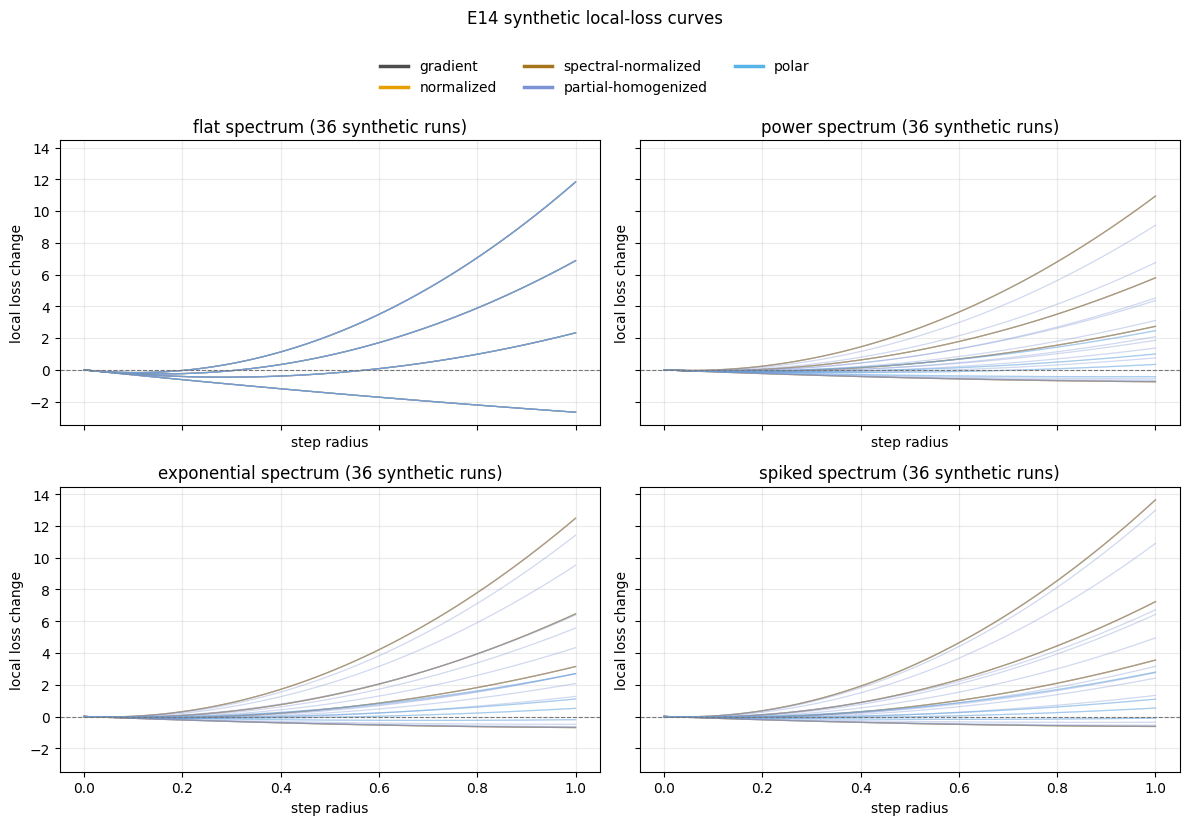

In [4]:
from matplotlib.lines import Line2D

METHOD_COLORS = {
    "gradient": "#4D4D4D",
    "normalized": "#E69F00",
    "spectral-normalized": "#A6761D",
    "partial-homogenized": "#7B92D4",
    "polar": "#56B4E9",
}


def local_quadratic_loss_change(s, curvature, method, gamma=0.5, radii=None):
    if radii is None:
        radii = np.linspace(0.0, 1.0, 101)
    direction = update_profile(method, s, gamma=gamma)
    h = curvature_weights(curvature, s)
    linear_gain = float(np.dot(s, direction))
    curvature_penalty = 0.5 * float(np.dot(h, direction**2))
    improvement = radii * linear_gain - (radii**2) * curvature_penalty
    return -improvement

fig, axes = plt.subplots(2, 2, figsize=(12, 7.6), sharex=True, sharey=True)
radii = np.linspace(0.0, 1.0, 101)
for ax, spectrum in zip(axes.ravel(), SPECTRA):
    line_count = 0
    for curvature, method in product(CURVATURES, METHODS):
        gammas = GAMMAS if method == "partial-homogenized" else [np.nan]
        for gamma in gammas:
            s = make_singular_values(spectrum, RANK)
            gamma_value = 0.5 if np.isnan(gamma) else gamma
            loss_change = local_quadratic_loss_change(s, curvature, method, gamma=gamma_value, radii=radii)
            ax.plot(radii, loss_change, color=METHOD_COLORS[method], linewidth=0.9, alpha=0.35)
            line_count += 1
    ax.axhline(0.0, color="#777777", linewidth=0.8, linestyle="--")
    ax.set_title(f"{spectrum} spectrum ({line_count} synthetic runs)")
    ax.set_xlabel("step radius")
    ax.set_ylabel("local loss change")
    ax.grid(alpha=0.25)
handles = [Line2D([0], [0], color=color, linewidth=2.5, label=method) for method, color in METHOD_COLORS.items()]
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.03), frameon=False)
fig.suptitle("E14 synthetic local-loss curves", y=1.08)
fig.tight_layout()
plt.show()


### Figure Discussion: Synthetic Local Loss Curves

These curves are not training runs. They are predicted local loss changes from a one-step quadratic model. Each panel fixes a gradient spectrum shape. Each line is one update rule under one curvature model. The x-axis is step radius, and the y-axis is predicted local loss change. Lower is better; below zero means the local model predicts the step decreases loss. When curves cross, the best update depends on step size and curvature. This is the main point of E14: polar/homogenized updates are not automatically best in every local geometry.


### Best Update By Curvature Regime

**What this table is:** the winner table for the synthetic local model.

- **Rows:** one `(gradient spectrum, curvature model)` regime.
- **method:** update rule with the best predicted one-step improvement in that regime.
- **gamma:** homogenization strength when the winner is partial homogenization.
- **predicted_improvement:** larger is better; negative values mean every tested unit-radius update is locally harmful, but the listed method is least bad.
- **How to read it:** if the winning method changes across rows, then no single update geometry is universally optimal.


In [5]:
best = results.sort_values("predicted_improvement", ascending=False).groupby(["spectrum", "curvature"], as_index=False, observed=True).head(1)
IPython.display.display(best.sort_values(["spectrum", "curvature"]))


,spectrum,curvature,method,gamma,predicted_improvement
97,exponential,exponential,partial-homogenized,1.0,-1.102277
89,exponential,polynomial,polar,NaN,-0.516362
75,exponential,quadratic,partial-homogenized,0.0,0.696246
106,exponential,threshold,partial-homogenized,1.0,-2.700860
20,flat,exponential,spectral-normalized,NaN,-6.880491
12,flat,polynomial,partial-homogenized,0.0,-2.337722
0,flat,quadratic,gradient,NaN,2.662278
29,flat,threshold,spectral-normalized,NaN,-11.837722
62,power,exponential,polar,NaN,-1.004223
53,power,polynomial,polar,NaN,-0.348663


### Improvement Curves

**What this plot is:** the same synthetic model summarized by curvature type for each spectrum.

- **One line:** one update rule.
- **X-axis:** curvature model.
- **Y-axis:** predicted local improvement; higher is better.
- **How to read it:** the plot shows whether polar, normalized, gradient-like, or partially homogenized updates are preferred under different curvature assumptions. Crossovers are the main point: they show regime dependence.


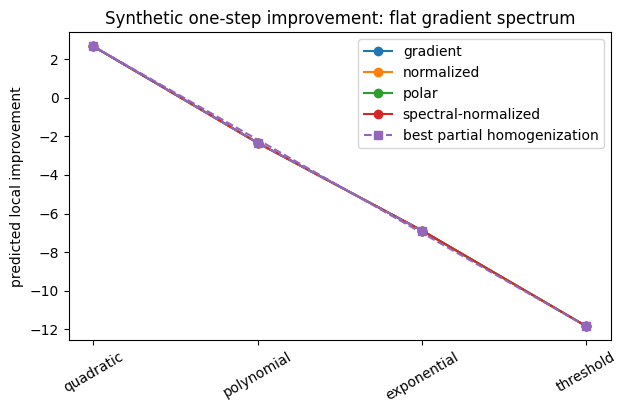

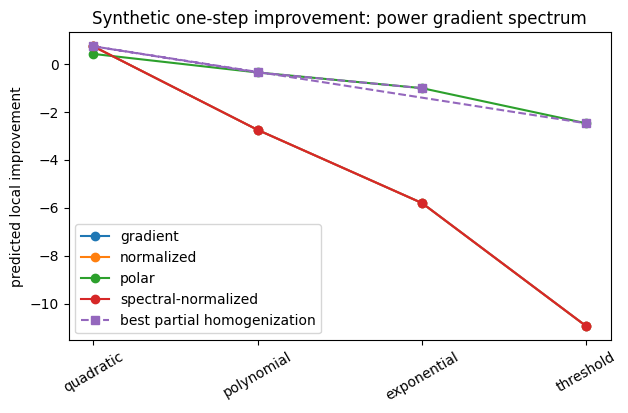

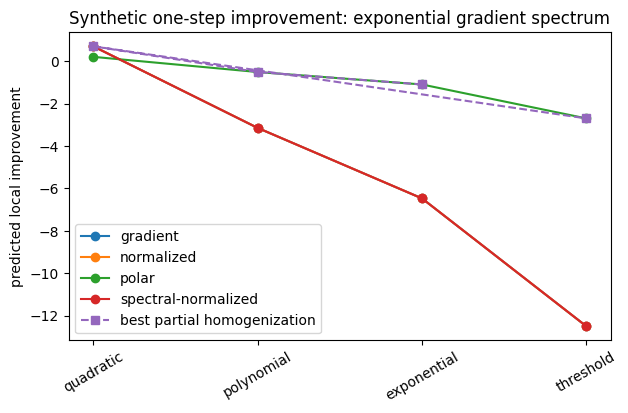

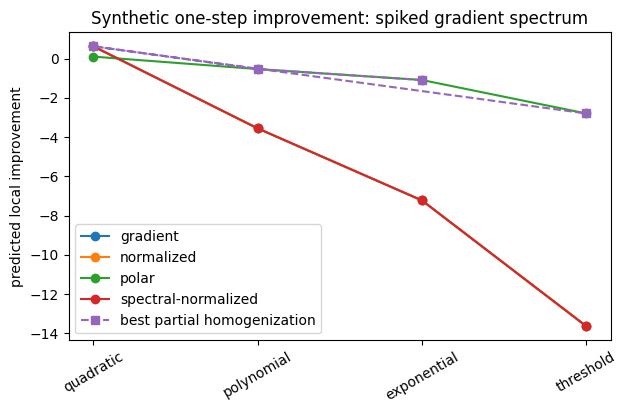

In [6]:
for spectrum in SPECTRA:
    fig, ax = plt.subplots(figsize=(7, 4))
    sub = results[(results["spectrum"] == spectrum) & (results["method"] != "partial-homogenized")]
    for method, group in sub.groupby("method", observed=True):
        ax.plot(group["curvature"], group["predicted_improvement"], marker="o", label=method)
    partial = results[(results["spectrum"] == spectrum) & (results["method"] == "partial-homogenized")].groupby("curvature", as_index=False, observed=True)["predicted_improvement"].max()
    ax.plot(partial["curvature"], partial["predicted_improvement"], marker="s", linestyle="--", label="best partial homogenization")
    ax.set_title(f"Synthetic one-step improvement: {spectrum} gradient spectrum")
    ax.set_ylabel("predicted local improvement")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
    plt.show()


### Figure Discussion: Improvement Curves

Each generated figure fixes one gradient spectrum and compares update rules across curvature models. The x-axis is curvature type; the y-axis is predicted one-step improvement, where higher is better. A line that is highest for one curvature type but not another means the preferred update rule changes with curvature. The dashed partial-homogenization line represents the best gamma value for that curvature, so it should be read as an optimized interpolation between gradient-like and polar-like behavior.


### Reading The Result

Read E14 as a controlled sanity check for the geometry story. It asks whether spectrum homogenization should always help, or only help when curvature makes that direction safe.

This experiment supports the isotropic-curvature story if the best update depends on curvature regime. Full polar orthogonalization should not dominate every regime; it should become most competitive in threshold-like curvature, while partial homogenization can be better under smooth curvature growth.


### Hypothesis Verdict Table

| hypothesis | evidence | supported? | caveat |
|---|---|---|---|
| Spectrum homogenization helps only in compatible curvature regimes. | The best-update table chooses different methods across spectrum and curvature cases, and local loss curves cross by regime. | Yes | This is a synthetic one-step local quadratic model, not a full training run. |
| Full polar updates should not dominate every curvature model. | Gradient-like, spectral-normalized, partial-homogenized, and polar updates each win in different cells of the table. | Yes | The result depends on the chosen curvature families and step-radius normalization. |
